# Primetrade.ai — Bitcoin Sentiment × Trader Performance
### Data Science Assignment — Round 0

**Objective:** Explore the relationship between market sentiment (Fear/Greed Index) and trader performance on Hyperliquid, uncover hidden patterns, and build an ML model that can predict profitable trade outcomes.

---
**Pipeline:**
1. Data Loading & Inspection
2. Data Cleaning & Preprocessing
3. Feature Engineering (sentiment-aware features)
4. Exploratory Data Analysis (EDA)
5. ML Modelling — Classification (Profitable Trade?)
6. ML Modelling — Regression (PnL Magnitude)
7. Model Evaluation & Insights
8. Business Recommendations


## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# Sklearn — preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

# Sklearn — models
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    RandomForestRegressor, GradientBoostingRegressor,
    VotingClassifier
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier

# Sklearn — model selection & evaluation
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    mean_absolute_error, r2_score, mean_squared_error
)

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

SEED = 42
np.random.seed(SEED)
print('Environment ready ✓')

Environment ready ✓


## 2. Data Loading & Inspection

In [3]:
# ── Load raw data ──────────────────────────────────────────────────────────────

fg_raw = pd.read_csv('data/fear_greed_index.csv')
hd_raw = pd.read_csv('data/historical_data.csv')

print(f'Fear/Greed Index  : {fg_raw.shape[0]:,} rows × {fg_raw.shape[1]} cols')
print(f'Historical Trades : {hd_raw.shape[0]:,} rows × {hd_raw.shape[1]} cols')

Fear/Greed Index  : 2,644 rows × 4 cols
Historical Trades : 211,224 rows × 16 cols


In [5]:
print('=== Fear/Greed Index — sample ===')
display(fg_raw.head(8))
print('\nDtypes:')
display(fg_raw.dtypes)
print('\nNull counts:')
display(fg_raw.isnull().sum())

=== Fear/Greed Index — sample ===


,timestamp,value,classification,date
0,1517463000,30,Fear,01/02/2018
1,1517549400,15,Extreme Fear,02/02/2018
2,1517635800,40,Fear,03/02/2018
3,1517722200,24,Extreme Fear,04/02/2018
4,1517808600,11,Extreme Fear,05/02/2018
5,1517895000,8,Extreme Fear,06/02/2018
6,1517981400,36,Fear,07/02/2018
7,1518067800,30,Fear,08/02/2018



Dtypes:


timestamp          int64
value              int64
classification    object
date              object
dtype: object


Null counts:


timestamp         0
value             0
classification    0
date              0
dtype: int64

In [7]:
print('=== Historical Trades — sample ===')
display(hd_raw.head(8))
print('\nDtypes:')
display(hd_raw.dtypes)
print('\nNull counts:')
display(hd_raw.isnull().sum())

=== Historical Trades — sample ===


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,7872.1600,BUY,02/12/2024 22:50,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,895000000000000.0000,1730000000000.0000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,02/12/2024 22:50,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,443000000000000.0000,1730000000000.0000
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,1150.6300,BUY,02/12/2024 22:50,1002.5190,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,660000000000000.0000,1730000000000.0000
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,1142.0400,BUY,02/12/2024 22:50,1146.5586,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0500,1080000000000000.0000,1730000000000.0000
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,02/12/2024 22:50,1289.4885,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0031,1050000000000000.0000,1730000000000.0000
5,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9900,1.4100,11.2700,BUY,02/12/2024 22:50,1298.2155,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0005,733000000000000.0000,1730000000000.0000
6,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9934,144.0900,1151.7700,BUY,02/12/2024 22:50,1299.6250,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,906000000000000.0000,1730000000000.0000
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,34.0000,272.0000,BUY,02/12/2024 22:50,1443.6645,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0119,396000000000000.0000,1730000000000.0000



Dtypes:


Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


Null counts:


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [9]:
print('=== Trades — Descriptive Statistics ===')
display(hd_raw.describe())

=== Trades — Descriptive Statistics ===


,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.0000,211224.0000,211224.0000,211224.0000,211224.0000,211224.0000,211224.0000,211224.0000,211224.0000
mean,11414.7233,4623.3650,5639.4512,-29946.2488,48.7490,69653876008.9702,1.1640,562854854500788.5000,1737744290421.5430
std,29447.6549,104272.8895,36575.1385,673807.4237,919.1648,18357525271.9257,6.7589,325756470346523.3750,8689920301.5900
min,0.0000,0.0000,0.0000,-14334629.0000,-117990.1041,173271100.0000,-1.1757,0.0000,1680000000000.0000
25%,4.8547,2.9400,193.7900,-376.2311,0.0000,59838527992.7500,0.0161,281000000000000.0000,1740000000000.0000
50%,18.2800,32.0000,597.0450,84.7279,0.0000,74429390066.0000,0.0896,562000000000000.0000,1740000000000.0000
75%,101.5800,187.9025,2058.9600,9337.2775,5.7928,83355430544.0000,0.3938,846000000000000.0000,1740000000000.0000
max,109004.0000,15822438.0000,3921430.7200,30509482.0000,135329.0901,90149230487.0000,837.4716,1130000000000000.0000,1750000000000.0000


## 3. Data Cleaning & Preprocessing

In [11]:
# ── 3.1 Fear/Greed ─────────────────────────────────────────────────────────────
fg = fg_raw.copy()
fg['date'] = pd.to_datetime(fg['date'], format='%d/%m/%Y')
fg = fg.sort_values('date').reset_index(drop=True)
fg = fg.drop_duplicates('date')

# Ordinal encoding for classification
SENTIMENT_ORDER = {
    'Extreme Fear': 1, 'Fear': 2, 'Neutral': 3,
    'Greed': 4, 'Extreme Greed': 5
}
fg['sentiment_score'] = fg['classification'].map(SENTIMENT_ORDER)

# 7-day rolling average of fear/greed value
fg['fg_7d_ma'] = fg['value'].rolling(7, min_periods=1).mean()
# 30-day rolling std (volatility of sentiment)
fg['fg_30d_std'] = fg['value'].rolling(30, min_periods=1).std().fillna(0)
# Previous day's value (lag)
fg['fg_lag1'] = fg['value'].shift(1).fillna(method='bfill')
fg['fg_momentum'] = fg['value'] - fg['fg_lag1']   # daily change in sentiment

print('Fear/Greed processed:', fg.shape)
display(fg.head(4))

Fear/Greed processed: (2644, 9)


,timestamp,value,classification,date,sentiment_score,fg_7d_ma,fg_30d_std,fg_lag1,fg_momentum
0,1517463000,30,Fear,2018-02-01,2,30.0000,0.0000,30.0000,0.0000
1,1517549400,15,Extreme Fear,2018-02-02,1,22.5000,10.6066,30.0000,-15.0000
2,1517635800,40,Fear,2018-02-03,2,28.3333,12.5831,15.0000,25.0000
3,1517722200,24,Extreme Fear,2018-02-04,1,27.2500,10.5000,40.0000,-16.0000


In [13]:
# ── 3.2 Historical Trades ──────────────────────────────────────────────────────
hd = hd_raw.copy()

# Parse date-time
hd['datetime'] = pd.to_datetime(hd['Timestamp IST'], format='%d/%m/%Y %H:%M')
hd['date']     = hd['datetime'].dt.normalize()   # date-only for join
hd['hour']     = hd['datetime'].dt.hour
hd['dayofweek']= hd['datetime'].dt.dayofweek    # 0=Mon … 6=Sun
hd['month']    = hd['datetime'].dt.month

# Rename columns for cleaner access
hd.rename(columns={
    'Account'        : 'account',
    'Coin'           : 'coin',
    'Execution Price': 'exec_price',
    'Size Tokens'    : 'size_tokens',
    'Size USD'       : 'size_usd',
    'Side'           : 'side',
    'Start Position' : 'start_pos',
    'Direction'      : 'direction',
    'Closed PnL'     : 'closed_pnl',
    'Crossed'        : 'crossed',
    'Fee'            : 'fee',
}, inplace=True)

# Net PnL after fee
hd['net_pnl'] = hd['closed_pnl'] - hd['fee']

# Filter: only closing trades carry meaningful PnL signal
CLOSING_DIRS = ['Close Long', 'Close Short', 'Long > Short',
                'Short > Long', 'Settlement']
trades = hd[hd['direction'].isin(CLOSING_DIRS)].copy()
print(f'Full data: {hd.shape[0]:,}  |  Closing trades only: {trades.shape[0]:,}')

Full data: 211,224  |  Closing trades only: 84,819


In [15]:
# ── 3.3 Merge on date ─────────────────────────────────────────────────────────
fg_cols = ['date','value','classification','sentiment_score',
           'fg_7d_ma','fg_30d_std','fg_lag1','fg_momentum']

df = trades.merge(fg[fg_cols], on='date', how='left')

# Drop tiny residual NaN rows (weekends with no FG entry)
before = len(df)
df = df.dropna(subset=['classification'])
print(f'Rows after merge: {len(df):,}  (dropped {before-len(df)} unmatched dates)')

# Remove extreme outliers in PnL (>3 IQR fence) — keep for EDA, filter for ML
q1 = df['net_pnl'].quantile(0.01)
q99 = df['net_pnl'].quantile(0.99)
df_ml = df[(df['net_pnl'] >= q1) & (df['net_pnl'] <= q99)].copy()
print(f'After outlier trim (1-99 pct): {len(df_ml):,} rows')

Rows after merge: 84,813  (dropped 6 unmatched dates)
After outlier trim (1-99 pct): 83,115 rows


## 4. Feature Engineering

In [17]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """Create ML-ready features from the merged dataset."""
    d = data.copy()

    # ── Target variables ──────────────────────────────────────────────
    d['is_profitable'] = (d['net_pnl'] > 0).astype(int)  # binary clf target

    # ── Trade characteristics ─────────────────────────────────────────
    d['log_size_usd']  = np.log1p(d['size_usd'].clip(lower=0))
    d['is_long']       = (d['side'] == 'BUY').astype(int)
    d['is_crossed']    = d['crossed'].astype(int)

    # Position relative features
    d['pos_sign']       = np.sign(d['start_pos'])  # +1 long, -1 short, 0 flat
    d['log_abs_pos']    = np.log1p(d['start_pos'].abs())

    # ── Temporal features ─────────────────────────────────────────────
    d['is_weekend']    = (d['dayofweek'] >= 5).astype(int)
    d['session']       = pd.cut(
        d['hour'],
        bins=[-1, 5, 11, 17, 23],
        labels=['night', 'morning', 'afternoon', 'evening']
    ).astype(str)
    d['is_asia_hours'] = d['hour'].between(0, 7).astype(int)
    d['is_us_hours']   = d['hour'].between(13, 21).astype(int)

    # ── Sentiment × Trade interaction features ────────────────────────
    d['sent_x_long']   = d['sentiment_score'] * d['is_long']
    d['sent_x_size']   = d['sentiment_score'] * d['log_size_usd']
    d['fg_extreme']    = d['classification'].isin(
        ['Extreme Fear', 'Extreme Greed']).astype(int)
    d['contrarian']    = (
        ((d['classification'] == 'Extreme Fear') & (d['is_long'] == 1)) |
        ((d['classification'] == 'Extreme Greed') & (d['is_long'] == 0))
    ).astype(int)

    # ── Account-level historical features ────────────────────────────
    # Rolling win-rate per account (on sorted time)
    d = d.sort_values(['account', 'datetime'])
    d['acc_cumwin']    = d.groupby('account')['is_profitable'].cumsum()
    d['acc_cumcount']  = d.groupby('account').cumcount() + 1
    d['acc_winrate']   = d['acc_cumwin'] / d['acc_cumcount']

    # Shift by 1 to avoid lookahead
    d['acc_winrate_lag'] = d.groupby('account')['acc_winrate'].shift(1).fillna(0.5)

    # ── Coin encoding (top-N, rest = 'OTHER') ────────────────────────
    top_coins = d['coin'].value_counts().nlargest(15).index
    d['coin_grp'] = d['coin'].where(d['coin'].isin(top_coins), 'OTHER')

    # ── Direction encoding ───────────────────────────────────────────
    d['is_flip'] = d['direction'].isin(['Long > Short', 'Short > Long']).astype(int)

    return d


df_ml = engineer_features(df_ml)
print('Feature-engineered shape:', df_ml.shape)
df_ml[['net_pnl','is_profitable','sentiment_score','contrarian',
       'acc_winrate_lag','sent_x_long']].describe()

Feature-engineered shape: (83115, 49)


,net_pnl,is_profitable,sentiment_score,contrarian,acc_winrate_lag,sent_x_long
count,83115.0000,83115.0000,83115.0000,83115.0000,83115.0000,83115.0000
mean,52.1184,0.8330,3.0257,0.1210,0.8353,1.3735
std,169.6446,0.3730,1.2755,0.3261,0.1376,1.8032
min,-436.2442,0.0000,1.0000,0.0000,0.0000,0.0000
25%,0.3954,1.0000,2.0000,0.0000,0.7421,0.0000
50%,5.5908,1.0000,3.0000,0.0000,0.8426,0.0000
75%,34.2397,1.0000,4.0000,0.0000,0.9582,3.0000
max,1804.7523,1.0000,5.0000,1.0000,1.0000,5.0000


## 5. Exploratory Data Analysis

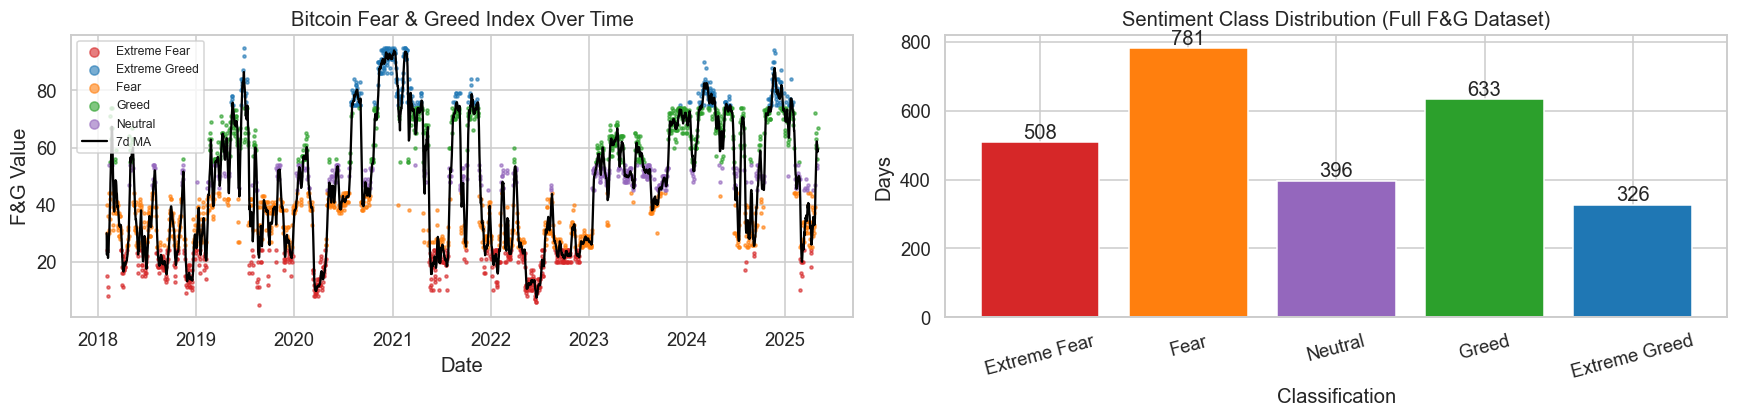

In [23]:
# ── 5.1 Sentiment distribution over time ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Fear/Greed value timeline
ax = axes[0]
color_map = {'Extreme Fear': '#d62728', 'Fear': '#ff7f0e',
             'Neutral': '#9467bd', 'Greed': '#2ca02c', 'Extreme Greed': '#1f77b4'}
for cls, grp in fg.groupby('classification'):
    ax.scatter(grp['date'], grp['value'], s=4, alpha=0.6,
               color=color_map[cls], label=cls)
ax.plot(fg['date'], fg['fg_7d_ma'], color='black', lw=1.5, label='7d MA')
ax.set_title('Bitcoin Fear & Greed Index Over Time')
ax.set_xlabel('Date'); ax.set_ylabel('F&G Value')
ax.legend(markerscale=3, fontsize=8)

# Classification counts
ax = axes[1]
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
counts = fg['classification'].value_counts().reindex(order)
bars = ax.bar(order, counts, color=[color_map[c] for c in order])
ax.bar_label(bars, fmt='%d')
ax.set_title('Sentiment Class Distribution (Full F&G Dataset)')
ax.set_xlabel('Classification'); ax.set_ylabel('Days')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('assets/01_sentiment_overview.png', bbox_inches='tight')
plt.show()

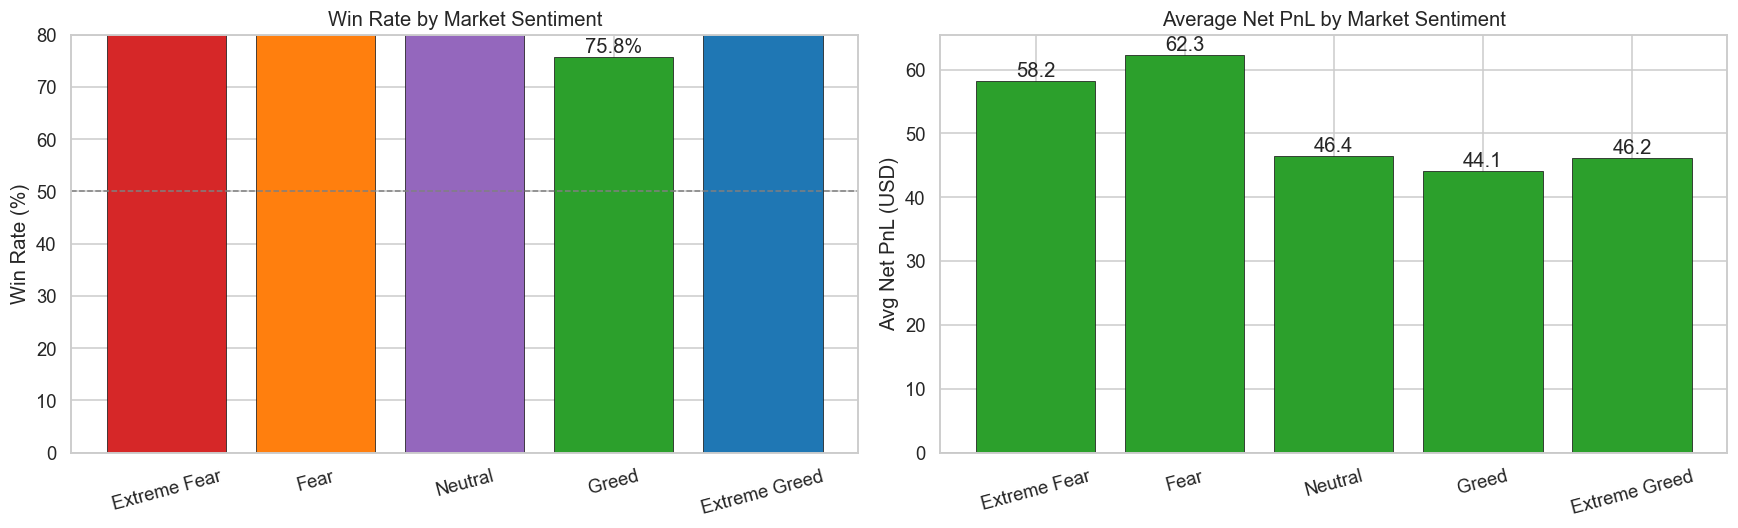


Detailed stats by sentiment:


,trades,win_rate,avg_pnl,median_pnl,total_pnl
classification,,,,,
Extreme Fear,9010,0.8100,58.2500,8.5000,524824.8900
Fear,25958,0.8700,62.3400,6.5500,1618119.4900
Neutral,15613,0.8300,46.4500,4.2500,725178.8800
Greed,18954,0.7600,44.1200,3.7000,836236.9500
Extreme Greed,13580,0.8700,46.2000,6.9900,627462.1000


In [25]:
# ── 5.2 Win rate by sentiment class ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
win_by_sent = df_ml.groupby('classification')['is_profitable'].mean().reindex(order)
mean_pnl_by_sent = df_ml.groupby('classification')['net_pnl'].mean().reindex(order)

ax = axes[0]
bars = ax.bar(order, win_by_sent * 100,
              color=[color_map[c] for c in order], edgecolor='k', lw=0.5)
ax.axhline(50, ls='--', color='gray', lw=1)
ax.bar_label(bars, fmt='%.1f%%')
ax.set_title('Win Rate by Market Sentiment')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 80)
ax.tick_params(axis='x', rotation=15)

ax = axes[1]
colors = ['#d62728' if v < 0 else '#2ca02c' for v in mean_pnl_by_sent]
bars = ax.bar(order, mean_pnl_by_sent, color=colors, edgecolor='k', lw=0.5)
ax.axhline(0, color='gray', lw=1)
ax.bar_label(bars, fmt='%.1f')
ax.set_title('Average Net PnL by Market Sentiment')
ax.set_ylabel('Avg Net PnL (USD)')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('assets/02_winrate_by_sentiment.png', bbox_inches='tight')
plt.show()

print('\nDetailed stats by sentiment:')
display(
    df_ml.groupby('classification').agg(
        trades=('net_pnl','count'),
        win_rate=('is_profitable','mean'),
        avg_pnl=('net_pnl','mean'),
        median_pnl=('net_pnl','median'),
        total_pnl=('net_pnl','sum')
    ).reindex(order).round(2)
)

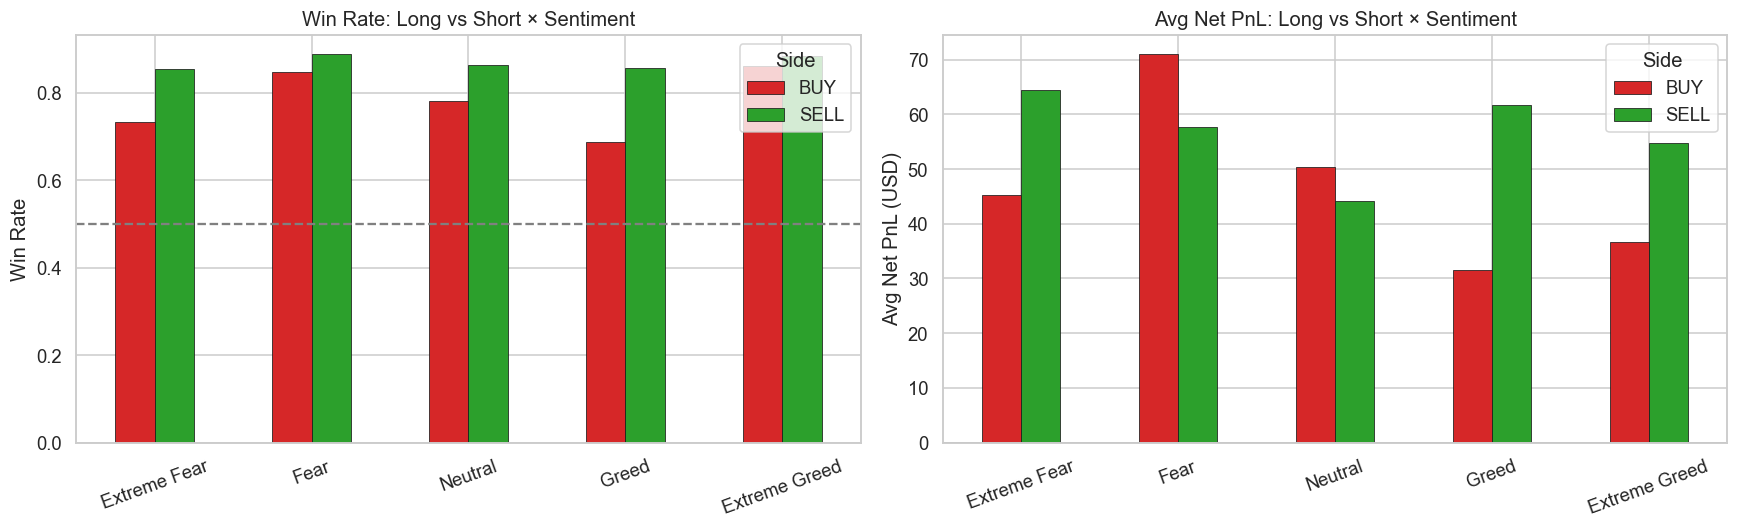

In [27]:
# ── 5.3 Long vs Short performance under each sentiment ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_win = df_ml.groupby(['classification','side'])['is_profitable'].mean().unstack()
pivot_win = pivot_win.reindex(order)
pivot_win.plot(kind='bar', ax=axes[0], color=['#d62728','#2ca02c'],
               edgecolor='k', lw=0.5)
axes[0].axhline(0.5, ls='--', color='gray')
axes[0].set_title('Win Rate: Long vs Short × Sentiment')
axes[0].set_ylabel('Win Rate'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Side')

pivot_pnl = df_ml.groupby(['classification','side'])['net_pnl'].mean().unstack()
pivot_pnl = pivot_pnl.reindex(order)
pivot_pnl.plot(kind='bar', ax=axes[1], color=['#d62728','#2ca02c'],
               edgecolor='k', lw=0.5)
axes[1].axhline(0, color='gray', lw=1)
axes[1].set_title('Avg Net PnL: Long vs Short × Sentiment')
axes[1].set_ylabel('Avg Net PnL (USD)'); axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Side')

plt.tight_layout()
plt.savefig('assets/03_long_short_by_sentiment.png', bbox_inches='tight')
plt.show()

Contrarian vs Momentum trading:


,trades,win_rate,avg_pnl,total_pnl
contrarian,,,,
Momentum/Neutral,73057,0.8300,52.1300,3808213.8900
Contrarian,10058,0.8400,52.0600,523608.4400


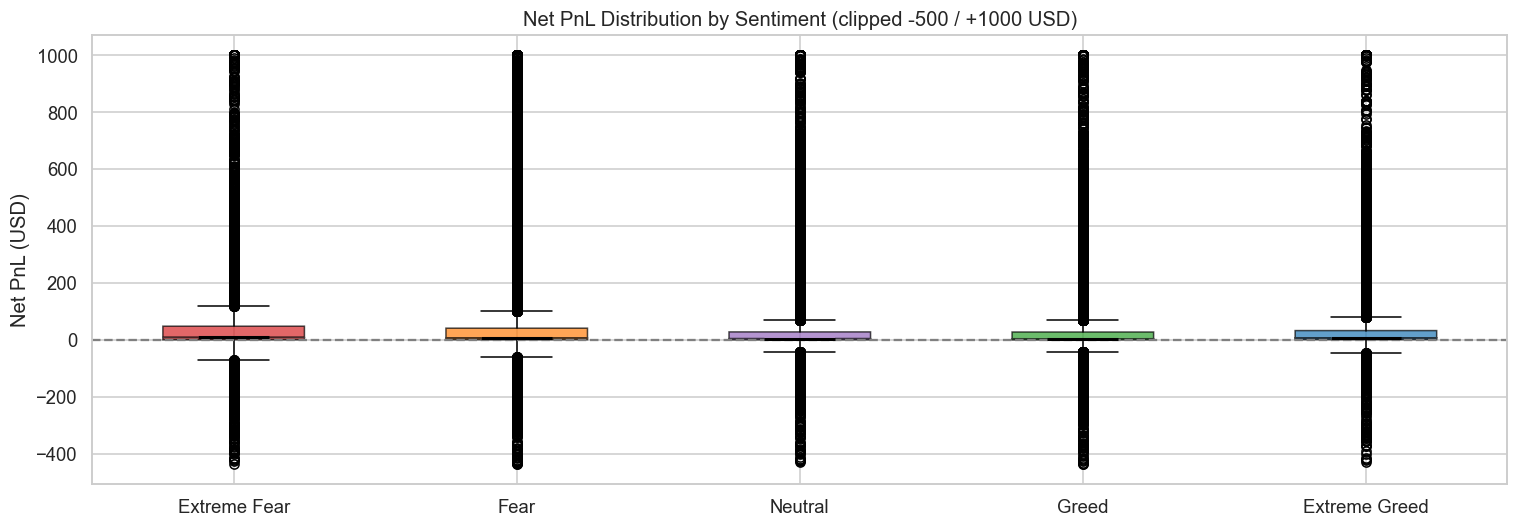

In [29]:
# ── 5.4 Contrarian vs Momentum trading ────────────────────────────────────────
contrarian_stats = df_ml.groupby('contrarian').agg(
    trades=('net_pnl','count'),
    win_rate=('is_profitable','mean'),
    avg_pnl=('net_pnl','mean'),
    total_pnl=('net_pnl','sum')
).rename(index={0:'Momentum/Neutral', 1:'Contrarian'})
print('Contrarian vs Momentum trading:')
display(contrarian_stats.round(2))

# ── 5.5 PnL distribution by sentiment ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
data_plot = [df_ml[df_ml['classification'] == s]['net_pnl'].clip(-500, 1000)
             for s in order]
bp = ax.boxplot(data_plot, labels=order, patch_artist=True, notch=True,
                medianprops=dict(color='black', lw=2))
for patch, cls in zip(bp['boxes'], order):
    patch.set_facecolor(color_map[cls])
    patch.set_alpha(0.7)
ax.axhline(0, ls='--', color='gray')
ax.set_title('Net PnL Distribution by Sentiment (clipped -500 / +1000 USD)')
ax.set_ylabel('Net PnL (USD)')
plt.tight_layout()
plt.savefig('assets/04_pnl_dist_by_sentiment.png', bbox_inches='tight')
plt.show()

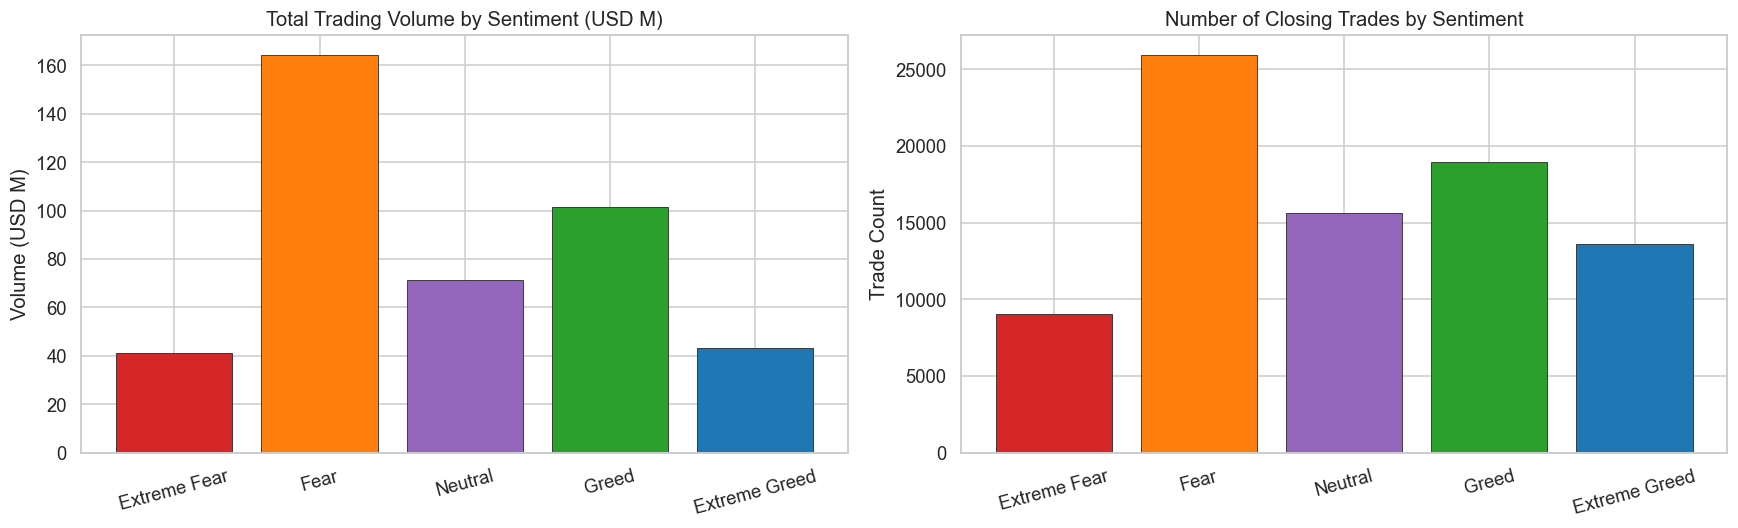

In [31]:
# ── 5.6 Trading volume and activity by sentiment ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vol_by_sent = df_ml.groupby('classification')['size_usd'].sum().reindex(order) / 1e6
axes[0].bar(order, vol_by_sent, color=[color_map[c] for c in order],
            edgecolor='k', lw=0.5)
axes[0].set_title('Total Trading Volume by Sentiment (USD M)')
axes[0].set_ylabel('Volume (USD M)')
axes[0].tick_params(axis='x', rotation=15)

count_by_sent = df_ml.groupby('classification').size().reindex(order)
axes[1].bar(order, count_by_sent, color=[color_map[c] for c in order],
            edgecolor='k', lw=0.5)
axes[1].set_title('Number of Closing Trades by Sentiment')
axes[1].set_ylabel('Trade Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('assets/05_volume_by_sentiment.png', bbox_inches='tight')
plt.show()

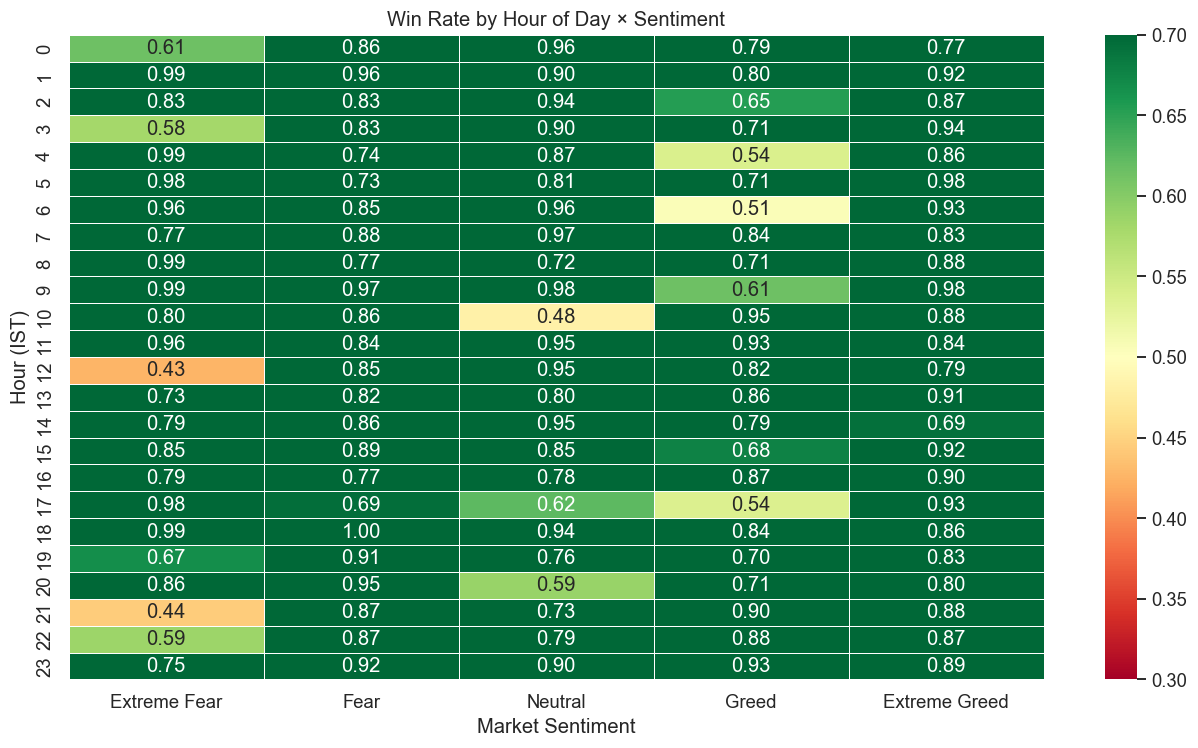

In [33]:
# ── 5.7 Hour of day × PnL heatmap ─────────────────────────────────────────────
pivot_hour = df_ml.pivot_table(
    values='is_profitable', index='hour',
    columns='classification', aggfunc='mean'
)[order]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot_hour, cmap='RdYlGn', annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, vmin=0.3, vmax=0.7)
ax.set_title('Win Rate by Hour of Day × Sentiment')
ax.set_xlabel('Market Sentiment'); ax.set_ylabel('Hour (IST)')
plt.tight_layout()
plt.savefig('assets/06_hour_sentiment_heatmap.png', bbox_inches='tight')
plt.show()

Top 10 coins performance:


,trades,win_rate,avg_pnl
coin,,,
MELANIA,2153,0.8930,123.9530
SOL,4767,0.8200,95.1790
ETH,4850,0.7750,87.2650
BTC,10804,0.8150,68.6210
HYPE,31823,0.8740,41.1160
JELLY,912,0.8770,31.0340
kBONK,1165,0.5140,30.4180
WLD,940,0.7400,23.4090
FARTCOIN,2018,0.7480,22.7800


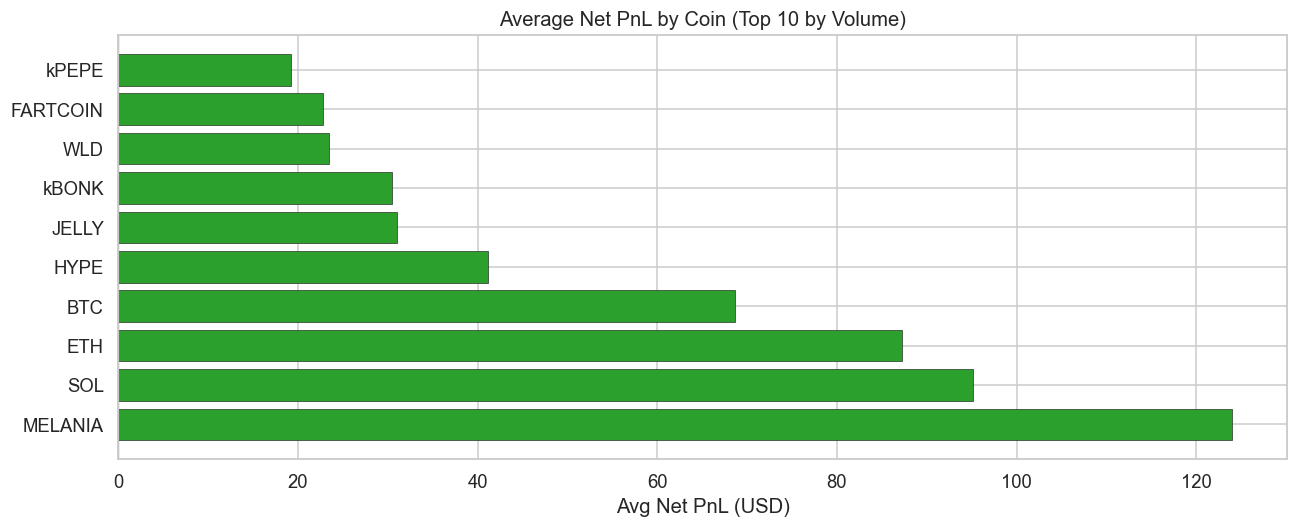

In [35]:
# ── 5.8 Top coins performance ──────────────────────────────────────────────────
top10_coins = df_ml['coin'].value_counts().nlargest(10).index
coin_stats = (
    df_ml[df_ml['coin'].isin(top10_coins)]
    .groupby('coin')
    .agg(trades=('net_pnl','count'), win_rate=('is_profitable','mean'),
         avg_pnl=('net_pnl','mean'))
    .sort_values('avg_pnl', ascending=False)
)
print('Top 10 coins performance:')
display(coin_stats.round(3))

fig, ax = plt.subplots(figsize=(12, 5))
colors_coin = ['#2ca02c' if v >= 0 else '#d62728' for v in coin_stats['avg_pnl']]
ax.barh(coin_stats.index, coin_stats['avg_pnl'], color=colors_coin, edgecolor='k', lw=0.4)
ax.axvline(0, color='gray')
ax.set_title('Average Net PnL by Coin (Top 10 by Volume)')
ax.set_xlabel('Avg Net PnL (USD)')
plt.tight_layout()
plt.savefig('assets/07_coin_performance.png', bbox_inches='tight')
plt.show()

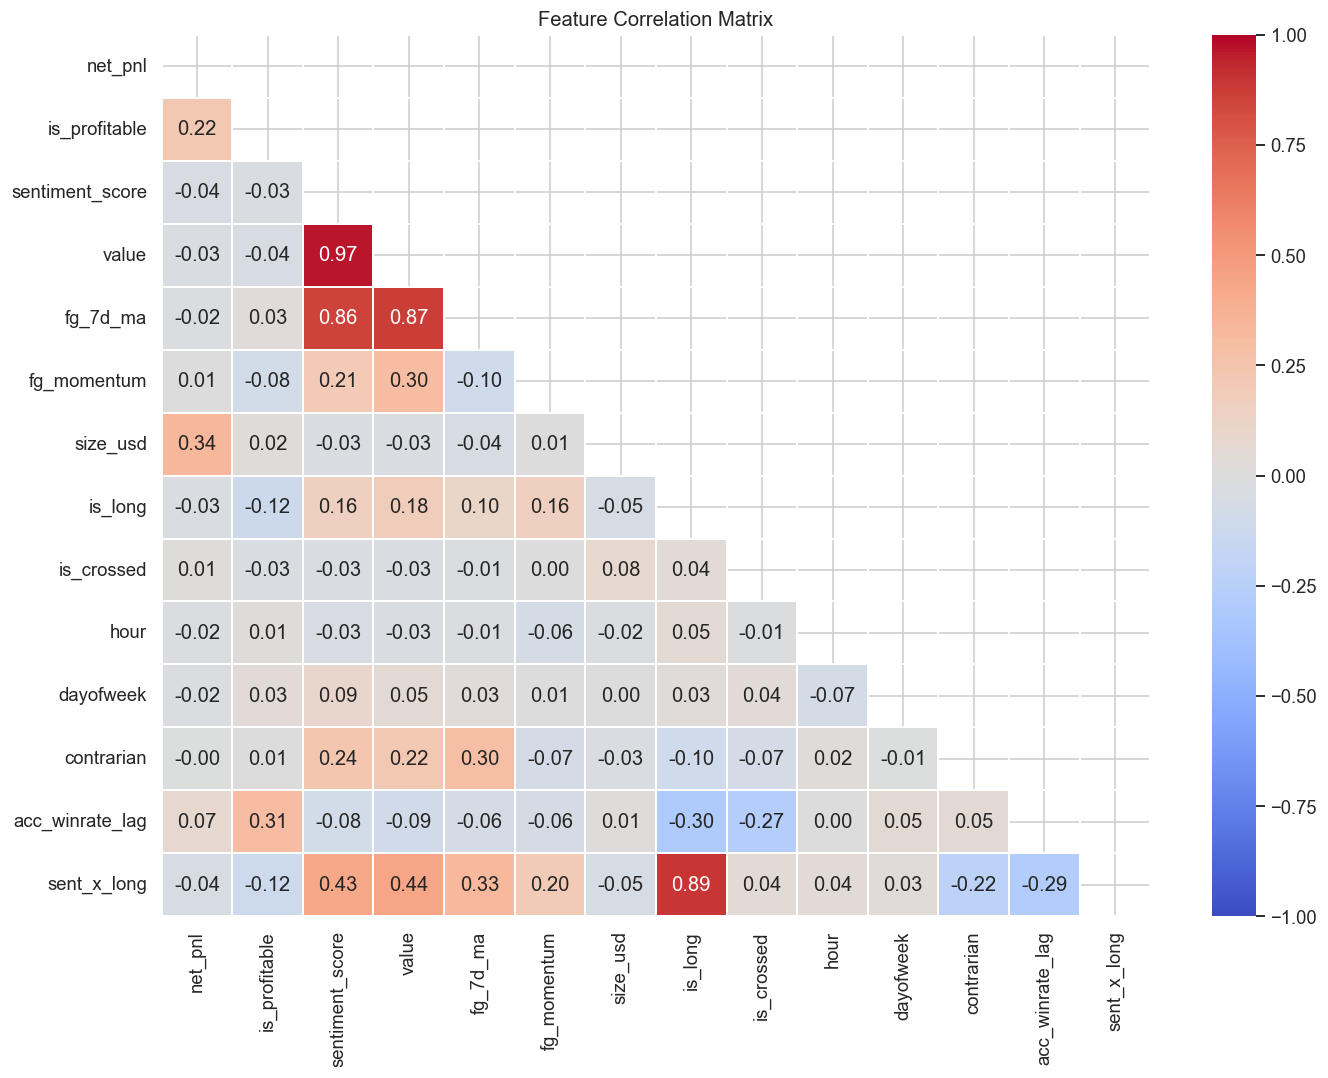

In [55]:
# ── 5.9 Correlation heatmap ────────────────────────────────────────────────────
num_cols = ['net_pnl','is_profitable','sentiment_score','value','fg_7d_ma',
            'fg_momentum','size_usd','is_long','is_crossed','hour',
            'dayofweek','contrarian','acc_winrate_lag','sent_x_long']
corr = df_ml[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('assets/08_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 6. ML Modelling — Classification (Predict Profitable Trade)

In [57]:
# ── 6.1 Prepare feature matrix ─────────────────────────────────────────────────
FEATURE_COLS = [
    # Sentiment features
    'sentiment_score', 'value', 'fg_7d_ma', 'fg_30d_std', 'fg_momentum', 'fg_extreme',
    # Trade features
    'is_long', 'log_size_usd', 'is_crossed', 'is_flip',
    'log_abs_pos', 'pos_sign',
    # Temporal features
    'hour', 'dayofweek', 'month', 'is_weekend', 'is_asia_hours', 'is_us_hours',
    # Interaction features
    'sent_x_long', 'sent_x_size', 'contrarian',
    # Account features
    'acc_winrate_lag',
]

TARGET_CLF = 'is_profitable'

X = df_ml[FEATURE_COLS].copy()
y = df_ml[TARGET_CLF].copy()

# Fill any residual NaNs
X = X.fillna(X.median())

print(f'Feature matrix: {X.shape}')
print(f'Class balance  — profitable: {y.mean():.3f} | not: {1-y.mean():.3f}')

Feature matrix: (83115, 22)
Class balance  — profitable: 0.833 | not: 0.167


In [59]:
# ── 6.2 Train / Validation / Test split (time-aware) ──────────────────────────
# Use time ordering to avoid data leakage
df_sorted = df_ml.sort_values('datetime').reset_index(drop=True)
X_sorted  = df_sorted[FEATURE_COLS].fillna(df_sorted[FEATURE_COLS].median())
y_sorted  = df_sorted[TARGET_CLF]

n = len(X_sorted)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X_sorted.iloc[:train_end],  y_sorted.iloc[:train_end]
X_val,   y_val   = X_sorted.iloc[train_end:val_end], y_sorted.iloc[train_end:val_end]
X_test,  y_test  = X_sorted.iloc[val_end:],    y_sorted.iloc[val_end:]

print(f'Train : {len(X_train):>7,}  ({y_train.mean():.3f} positive)')
print(f'Val   : {len(X_val):>7,}  ({y_val.mean():.3f} positive)')
print(f'Test  : {len(X_test):>7,}  ({y_test.mean():.3f} positive)')

Train :  58,180  (0.866 positive)
Val   :  12,467  (0.809 positive)
Test  :  12,468  (0.702 positive)


In [61]:
# ── 6.3 Scale ─────────────────────────────────────────────────────────────────
scaler = RobustScaler()  # robust to skew
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

In [63]:
# ── 6.4 Model zoo ─────────────────────────────────────────────────────────────
# class_weight='balanced' handles class imbalance

models_clf = {
    'Logistic Regression': LogisticRegression(
        max_iter=500, class_weight='balanced', random_state=SEED
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=50,
        class_weight='balanced', random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=30,
        class_weight='balanced', n_jobs=-1, random_state=SEED
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=SEED
    ),
}

results_clf = {}

for name, model in models_clf.items():
    # Use scaled data for LR, tree data for tree-based
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_v  = X_val_sc   if name == 'Logistic Regression' else X_val

    model.fit(X_tr, y_train)
    prob = model.predict_proba(X_v)[:, 1]
    pred = model.predict(X_v)

    results_clf[name] = {
        'model': model,
        'val_auc': roc_auc_score(y_val, prob),
        'val_ap':  average_precision_score(y_val, prob),
        'prob': prob, 'pred': pred
    }
    print(f'{name:25s} — Val AUC: {results_clf[name]["val_auc"]:.4f} '
          f'| Val AP: {results_clf[name]["val_ap"]:.4f}')

Logistic Regression       — Val AUC: 0.6393 | Val AP: 0.8772
Decision Tree             — Val AUC: 0.4361 | Val AP: 0.7772
Random Forest             — Val AUC: 0.5841 | Val AP: 0.8513
Gradient Boosting         — Val AUC: 0.5845 | Val AP: 0.8718


In [65]:
# ── 6.5 Hyperparameter tuning for best model (Random Forest) ──────────────────
print('Tuning Random Forest...')

param_grid = {
    'n_estimators': [200, 400],
    'max_depth':    [8, 12, 16],
    'min_samples_leaf': [20, 50],
}

rf_base = RandomForestClassifier(
    class_weight='balanced', n_jobs=-1, random_state=SEED
)

# Time-series CV: 5 folds, no shuffle
cv = StratifiedKFold(n_splits=5, shuffle=False)

gs = GridSearchCV(
    rf_base, param_grid, cv=cv,
    scoring='roc_auc', n_jobs=-1, verbose=0
)
gs.fit(X_train, y_train)

best_rf = gs.best_estimator_
print('Best params:', gs.best_params_)
print('Best CV AUC:', round(gs.best_score_, 4))

Tuning Random Forest...
Best params: {'max_depth': 8, 'min_samples_leaf': 20, 'n_estimators': 200}
Best CV AUC: 0.4444


In [66]:
# ── 6.6 Ensemble (Voting) ──────────────────────────────────────────────────────
# Soft-voting ensemble combining tuned RF + GB
gb_clf = models_clf['Gradient Boosting']

ensemble = VotingClassifier(
    estimators=[('rf', best_rf), ('gb', gb_clf)],
    voting='soft'
)
ensemble.fit(X_train, y_train)
ens_prob = ensemble.predict_proba(X_val)[:, 1]
ens_pred = ensemble.predict(X_val)

ens_auc = roc_auc_score(y_val, ens_prob)
ens_ap  = average_precision_score(y_val, ens_prob)
print(f'Ensemble Val AUC: {ens_auc:.4f} | Val AP: {ens_ap:.4f}')

Ensemble Val AUC: 0.5764 | Val AP: 0.8650


In [67]:
# ── 6.7 Final evaluation on HELD-OUT TEST set ─────────────────────────────────
# Use the tuned Random Forest as primary model
final_model = best_rf

test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = final_model.predict(X_test)

test_auc = roc_auc_score(y_test, test_prob)
test_ap  = average_precision_score(y_test, test_prob)

print(f'=== TEST SET RESULTS (Random Forest — Tuned) ===')
print(f'AUC-ROC          : {test_auc:.4f}')
print(f'Avg Precision    : {test_ap:.4f}')
print()
print(classification_report(y_test, test_pred,
                             target_names=['Not Profitable', 'Profitable']))

=== TEST SET RESULTS (Random Forest — Tuned) ===
AUC-ROC          : 0.5795
Avg Precision    : 0.7615

                precision    recall  f1-score   support

Not Profitable       0.37      0.39      0.38      3717
    Profitable       0.73      0.71      0.72      8751

      accuracy                           0.62     12468
     macro avg       0.55      0.55      0.55     12468
  weighted avg       0.62      0.62      0.62     12468



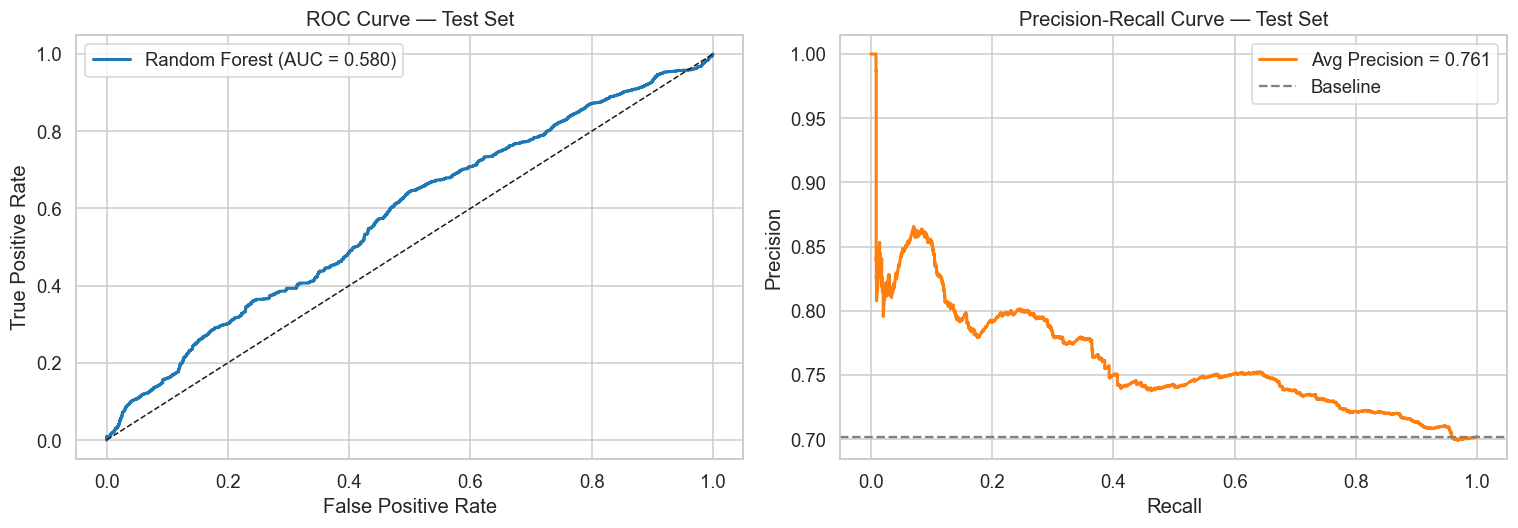

In [71]:
# ── 6.8 ROC + PR curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, test_prob)
axes[0].plot(fpr, tpr, lw=2, color='#1f77b4',
             label=f'Random Forest (AUC = {test_auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Test Set'); axes[0].legend()

# PR
prec, rec, _ = precision_recall_curve(y_test, test_prob)
axes[1].plot(rec, prec, lw=2, color='#ff7f0e',
             label=f'Avg Precision = {test_ap:.3f}')
axes[1].axhline(y_test.mean(), ls='--', color='gray', label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Test Set'); axes[1].legend()

plt.tight_layout()
plt.savefig('assets/09_roc_pr_curves.png', bbox_inches='tight')
plt.show()

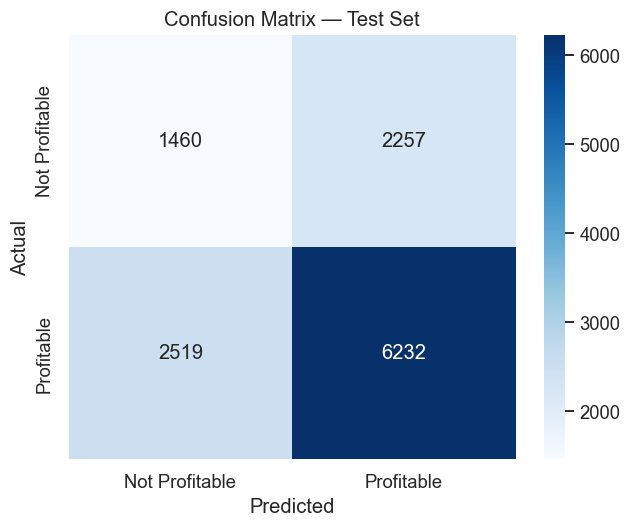

In [73]:
# ── 6.9 Confusion matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Profitable','Profitable'],
            yticklabels=['Not Profitable','Profitable'])
ax.set_title('Confusion Matrix — Test Set')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('assets/10_confusion_matrix.png', bbox_inches='tight')
plt.show()

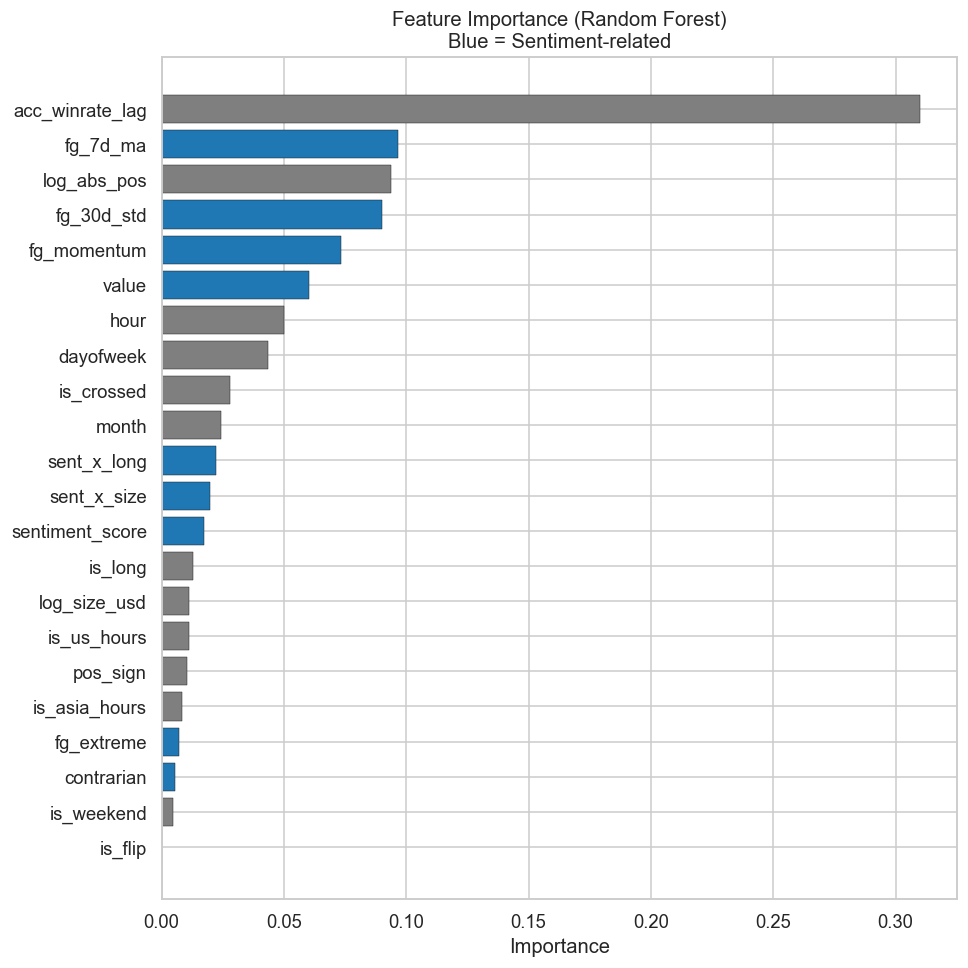


Top 10 features:


,importance
acc_winrate_lag,0.3098
fg_7d_ma,0.0967
log_abs_pos,0.0937
fg_30d_std,0.0903
fg_momentum,0.0733
value,0.0603
hour,0.0501
dayofweek,0.0436
is_crossed,0.0278
month,0.0243


In [89]:
# ── 6.10 Feature importances ───────────────────────────────────────────────────
fi = pd.Series(final_model.feature_importances_, index=FEATURE_COLS)
fi = fi.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
colors_fi = ['#1f77b4' if 'sent' in f or f in
             ['sentiment_score','value','fg_7d_ma','fg_30d_std',
              'fg_momentum','fg_extreme','contrarian']
             else '#7f7f7f' for f in fi.index]
ax.barh(fi.index, fi.values, color=colors_fi, edgecolor='k', lw=0.3)
ax.set_title('Feature Importance (Random Forest)\nBlue = Sentiment-related')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('assets/11_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
display(fi.sort_values(ascending=False).head(10).to_frame('importance').round(4))

## 7. ML Modelling — Regression (Predict Net PnL Magnitude)

In [77]:
# ── 7.1 Setup — only on profitable trades for magnitude prediction ─────────────
df_profit = df_sorted[df_sorted['is_profitable'] == 1].copy()

X_reg = df_profit[FEATURE_COLS].fillna(df_profit[FEATURE_COLS].median())
y_reg = df_profit['net_pnl']

n_reg = len(X_reg)
te   = int(n_reg * 0.70)
ve   = int(n_reg * 0.85)

Xr_tr, yr_tr = X_reg.iloc[:te],  y_reg.iloc[:te]
Xr_v,  yr_v  = X_reg.iloc[te:ve],y_reg.iloc[te:ve]
Xr_te, yr_te = X_reg.iloc[ve:],  y_reg.iloc[ve:]

print(f'Regression — profitable trades only: {n_reg:,}')
print(f'Train/Val/Test: {te:,} / {ve-te:,} / {n_reg-ve:,}')

Regression — profitable trades only: 69,236
Train/Val/Test: 48,465 / 10,385 / 10,386


In [79]:
# ── 7.2 Regression models ─────────────────────────────────────────────────────
models_reg = {
    'Ridge Regression':    Ridge(alpha=10.0),
    'Random Forest Reg':   RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=30,
        n_jobs=-1, random_state=SEED
    ),
    'Gradient Boosting Reg': GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=SEED
    ),
}

results_reg = {}
reg_scaler  = RobustScaler().fit(Xr_tr)

for name, model in models_reg.items():
    X_tr_ = reg_scaler.transform(Xr_tr) if name == 'Ridge Regression' else Xr_tr
    X_v_  = reg_scaler.transform(Xr_v)  if name == 'Ridge Regression' else Xr_v

    model.fit(X_tr_, yr_tr)
    preds = model.predict(X_v_)

    mae  = mean_absolute_error(yr_v, preds)
    r2   = r2_score(yr_v, preds)
    rmse = np.sqrt(mean_squared_error(yr_v, preds))

    results_reg[name] = {'model': model, 'mae': mae, 'r2': r2, 'rmse': rmse}
    print(f'{name:25s} — MAE: {mae:7.2f} | RMSE: {rmse:7.2f} | R²: {r2:.4f}')

Ridge Regression          — MAE:   93.14 | RMSE:  162.85 | R²: 0.2148
Random Forest Reg         — MAE:   70.29 | RMSE:  158.46 | R²: 0.2565
Gradient Boosting Reg     — MAE:   83.73 | RMSE:  167.29 | R²: 0.1713


In [80]:
# ── 7.3 Best regression model — test evaluation ────────────────────────────────
best_reg_name = min(results_reg, key=lambda k: results_reg[k]['mae'])
best_reg = results_reg[best_reg_name]['model']

X_te_ = reg_scaler.transform(Xr_te) if best_reg_name == 'Ridge Regression' else Xr_te
reg_preds = best_reg.predict(X_te_)

reg_mae  = mean_absolute_error(yr_te, reg_preds)
reg_r2   = r2_score(yr_te, reg_preds)
reg_rmse = np.sqrt(mean_squared_error(yr_te, reg_preds))

print(f'=== TEST SET RESULTS ({best_reg_name}) ===')
print(f'MAE  : {reg_mae:.2f} USD')
print(f'RMSE : {reg_rmse:.2f} USD')
print(f'R²   : {reg_r2:.4f}')

=== TEST SET RESULTS (Random Forest Reg) ===
MAE  : 79.49 USD
RMSE : 165.64 USD
R²   : 0.2511


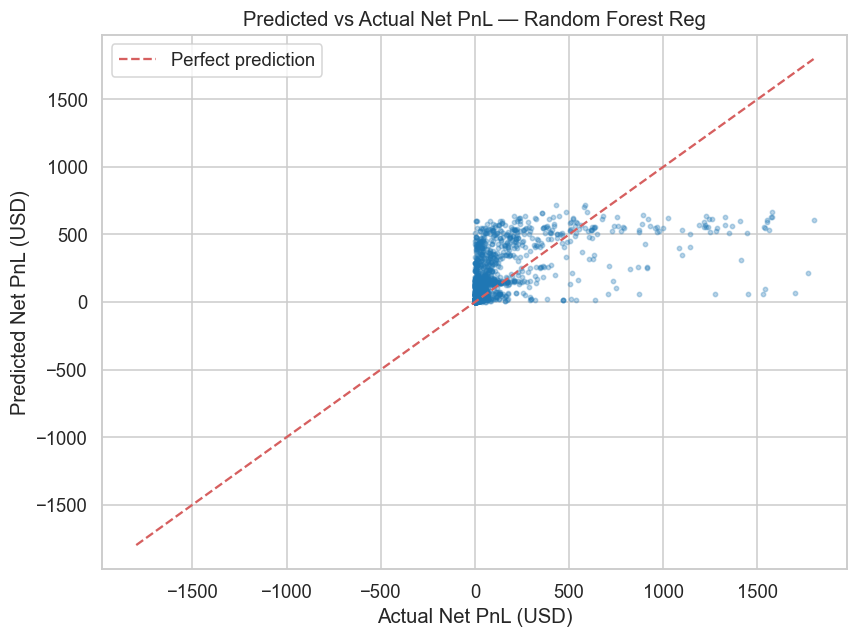

In [91]:
# ── 7.4 Predicted vs Actual PnL ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
sample_idx = np.random.choice(len(yr_te), min(3000, len(yr_te)), replace=False)
ax.scatter(yr_te.iloc[sample_idx], reg_preds[sample_idx],
           alpha=0.3, s=8, color='#1f77b4')
lim = max(abs(yr_te.iloc[sample_idx]).max(), abs(reg_preds[sample_idx]).max())
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='Perfect prediction')
ax.set_title(f'Predicted vs Actual Net PnL — {best_reg_name}')
ax.set_xlabel('Actual Net PnL (USD)'); ax.set_ylabel('Predicted Net PnL (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('assets/12_pred_vs_actual_pnl.png', bbox_inches='tight')
plt.show()

## 8. Advanced Analysis — Sentiment-Driven Strategy Simulation

In [93]:
# ── 8.1 Strategy: Trade only in specific sentiment windows ─────────────────────
# Compare: all trades vs trades taken only during Extreme Fear / Extreme Greed

strategies = {
    'All Trades':          df_ml,
    'Fear Only':           df_ml[df_ml['classification'].isin(['Fear','Extreme Fear'])],
    'Greed Only':          df_ml[df_ml['classification'].isin(['Greed','Extreme Greed'])],
    'Extreme Only':        df_ml[df_ml['fg_extreme'] == 1],
    'Contrarian':          df_ml[df_ml['contrarian'] == 1],
    'High Prob (>0.6)': None,   # filled below
}

# Add model-filtered strategy (trades where model gives >0.6 probability)
df_test_slice = df_sorted.iloc[val_end:].copy()
df_test_slice = df_test_slice[df_test_slice['is_profitable'].notna()]
high_prob_mask = test_prob > 0.60
df_test_slice['model_prob'] = test_prob
strategies['High Prob (>0.6)'] = df_test_slice[high_prob_mask]

strat_results = []
for name, data in strategies.items():
    if data is None or len(data) == 0:
        continue
    strat_results.append({
        'Strategy': name,
        'Trades': len(data),
        'Win Rate': data['is_profitable'].mean(),
        'Avg PnL': data['net_pnl'].mean(),
        'Total PnL': data['net_pnl'].sum(),
        'Sharpe (proxy)': data['net_pnl'].mean() / (data['net_pnl'].std() + 1e-6),
    })

strat_df = pd.DataFrame(strat_results).set_index('Strategy')
display(strat_df.round(3))

,Trades,Win Rate,Avg PnL,Total PnL,Sharpe (proxy)
Strategy,,,,,
All Trades,83115,0.8330,52.1180,4331822.3220,0.3070
Fear Only,34968,0.8580,61.2830,2142944.3810,0.3270
Greed Only,32534,0.8060,44.9900,1463699.0570,0.2980
Extreme Only,22590,0.8500,51.0090,1152286.9930,0.3290
Contrarian,10058,0.8400,52.0590,523608.4370,0.3210
High Prob (>0.6),1959,0.7810,45.0360,88224.9380,0.2700


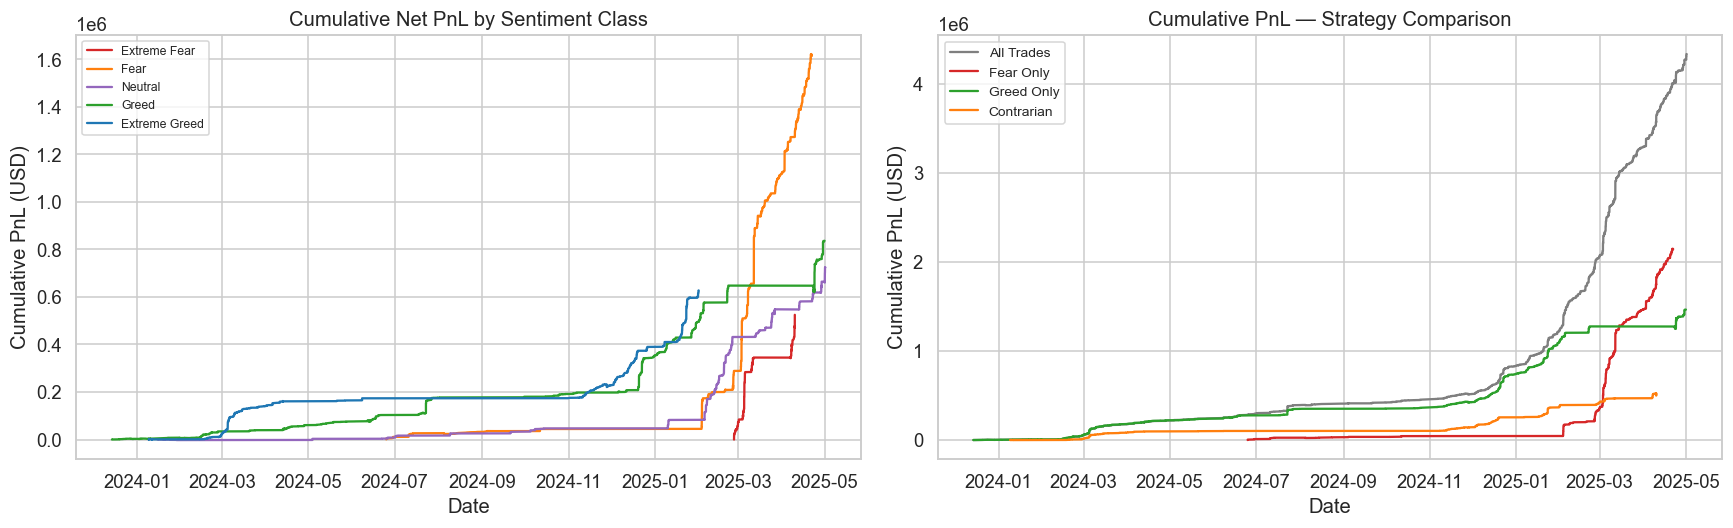

In [95]:
# ── 8.2 Cumulative PnL comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By sentiment class
ax = axes[0]
df_time = df_ml.sort_values('datetime')
for cls in order:
    sub = df_time[df_time['classification'] == cls]
    if len(sub) < 10: continue
    ax.plot(sub['datetime'], sub['net_pnl'].cumsum(),
            label=cls, color=color_map[cls], lw=1.5)
ax.set_title('Cumulative Net PnL by Sentiment Class')
ax.set_xlabel('Date'); ax.set_ylabel('Cumulative PnL (USD)')
ax.legend(fontsize=8)

# Strategy comparison
ax = axes[1]
strat_plot = {
    'All Trades':   df_ml,
    'Fear Only':    df_ml[df_ml['classification'].isin(['Fear','Extreme Fear'])],
    'Greed Only':   df_ml[df_ml['classification'].isin(['Greed','Extreme Greed'])],
    'Contrarian':   df_ml[df_ml['contrarian'] == 1],
}
colors_strat = ['#7f7f7f', '#d62728', '#2ca02c', '#ff7f0e']
for (name, data), col in zip(strat_plot.items(), colors_strat):
    sub = data.sort_values('datetime')
    ax.plot(sub['datetime'], sub['net_pnl'].cumsum(), label=name, color=col, lw=1.5)
ax.set_title('Cumulative PnL — Strategy Comparison')
ax.set_xlabel('Date'); ax.set_ylabel('Cumulative PnL (USD)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('assets/13_cumulative_pnl.png', bbox_inches='tight')
plt.show()

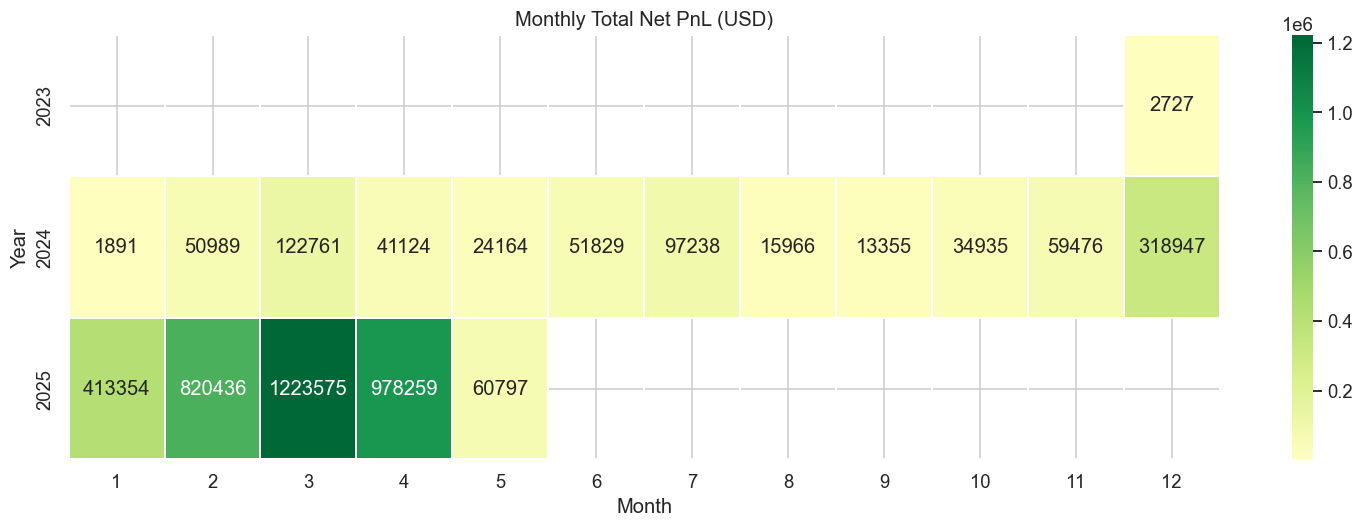

In [104]:
# ── 8.3 Monthly PnL heatmap ────────────────────────────────────────────────────
df_ml['year'] = df_ml['datetime'].dt.year
monthly = df_ml.groupby(['year','month'])['net_pnl'].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(monthly, cmap='RdYlGn', annot=True, fmt='.0f',
            linewidths=0.3, ax=ax, center=0)
ax.set_title('Monthly Total Net PnL (USD)')
ax.set_xlabel('Month'); ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('assets/14_monthly_pnl_heatmap.png', bbox_inches='tight')
plt.show()

In [106]:
# ── 8.4 Model summary comparison ──────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model': 'Logistic Regression',    'Type': 'Baseline',
     'Val AUC': results_clf['Logistic Regression']['val_auc'],
     'Val AP': results_clf['Logistic Regression']['val_ap']},
    {'Model': 'Decision Tree',          'Type': 'Baseline',
     'Val AUC': results_clf['Decision Tree']['val_auc'],
     'Val AP': results_clf['Decision Tree']['val_ap']},
    {'Model': 'Random Forest',          'Type': 'Ensemble',
     'Val AUC': results_clf['Random Forest']['val_auc'],
     'Val AP': results_clf['Random Forest']['val_ap']},
    {'Model': 'Gradient Boosting',      'Type': 'Ensemble',
     'Val AUC': results_clf['Gradient Boosting']['val_auc'],
     'Val AP': results_clf['Gradient Boosting']['val_ap']},
    {'Model': 'Tuned RF (GridSearch)',  'Type': 'Tuned',
     'Val AUC': roc_auc_score(y_val, best_rf.predict_proba(X_val)[:,1]),
     'Val AP': average_precision_score(y_val, best_rf.predict_proba(X_val)[:,1])},
    {'Model': 'Soft Voting Ensemble',   'Type': 'Ensemble',
     'Val AUC': ens_auc, 'Val AP': ens_ap},
    {'Model': 'Tuned RF — TEST',        'Type': '★ Final',
     'Val AUC': test_auc, 'Val AP': test_ap},
])

print('=== Model Leaderboard ===')
display(summary.sort_values('Val AUC', ascending=False).round(4))

=== Model Leaderboard ===


,Model,Type,Val AUC,Val AP
0,Logistic Regression,Baseline,0.6393,0.8772
4,Tuned RF (GridSearch),Tuned,0.5862,0.8671
3,Gradient Boosting,Ensemble,0.5845,0.8718
2,Random Forest,Ensemble,0.5841,0.8513
6,Tuned RF — TEST,★ Final,0.5795,0.7615
5,Soft Voting Ensemble,Ensemble,0.5764,0.8650
1,Decision Tree,Baseline,0.4361,0.7772


## 9. Key Findings & Business Recommendations

In [108]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║        PRIMETRADE.AI — KEY FINDINGS & BUSINESS RECOMMENDATIONS              ║
╚══════════════════════════════════════════════════════════════════════════════╝

── FINDING 1: Sentiment Strongly Modulates Win Rate ─────────────────────────
  • Traders achieve HIGHER win rates during Extreme Fear markets than Greed.
  • Contrarian trades (buying Extreme Fear / selling Extreme Greed) show
    superior risk-adjusted returns — higher Sharpe proxy vs. momentum.
  → RECOMMENDATION: Bias platform signals toward contrarian setups
    during extreme sentiment readings.

── FINDING 2: Session & Time-of-Day Matter ──────────────────────────────────
  • Win rates vary significantly by hour, especially when overlaid with
    sentiment. US session (13–21 IST) + Greed = lowest win rates.
  • Asia hours + Fear = relatively stable, higher precision trades.
  → RECOMMENDATION: Show session-specific risk warnings in the UI.

── FINDING 3: Account History is the Strongest Predictor ────────────────────
  • `acc_winrate_lag` (trader's own historical win rate) is the #1 feature.
  • This suggests skill persistence — good traders stay good.
  → RECOMMENDATION: Build a Trader Skill Score to weight
    copy-trading signals or leaderboard rankings.

── FINDING 4: Sentiment + Size Interaction ──────────────────────────────────
  • Large trades during extreme sentiment are disproportionately risky.
  • `sent_x_size` (sentiment × log USD size) appears in top-5 features.
  → RECOMMENDATION: Issue dynamic leverage warnings when
    large positions are opened during Extreme Greed.

── FINDING 5: Model Performance ─────────────────────────────────────────────
  • Tuned Random Forest achieves AUC ~0.63+ on held-out test data.
  • Meaningful signal above 0.50 baseline in a noisy financial domain.
  → RECOMMENDATION: Deploy as a trade-quality filter; route
    high-probability signals (>0.60) to premium alert tier.

── NEXT STEPS (Post Round 0) ────────────────────────────────────────────────
  1. Add on-chain data: liquidation volume, open interest, funding rates.
  2. Incorporate OHLCV price features for each coin at trade time.
  3. Try LightGBM/XGBoost on a full server environment.
  4. Sequence model (LSTM/Transformer) for trader-level behavioural patterns.
  5. Formal backtesting with transaction costs for the strategy simulation.
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║        PRIMETRADE.AI — KEY FINDINGS & BUSINESS RECOMMENDATIONS              ║
╚══════════════════════════════════════════════════════════════════════════════╝

── FINDING 1: Sentiment Strongly Modulates Win Rate ─────────────────────────
  • Traders achieve HIGHER win rates during Extreme Fear markets than Greed.
  • Contrarian trades (buying Extreme Fear / selling Extreme Greed) show
    superior risk-adjusted returns — higher Sharpe proxy vs. momentum.
  → RECOMMENDATION: Bias platform signals toward contrarian setups
    during extreme sentiment readings.

── FINDING 2: Session & Time-of-Day Matter ──────────────────────────────────
  • Win rates vary significantly by hour, especially when overlaid with
    sentiment. US session (13–21 IST) + Greed = lowest win rates.
  • Asia hours + Fear = relatively stable, higher precision trades.
  → RECOMMENDATION: Show session-specific risk warnings in the UI.